1. Load the Iris dataset using Python's sklearn, perform hierarchical clustering with the 'ward' linkage, and plot the resulting dendrogram using scipy's dendrogram() function.


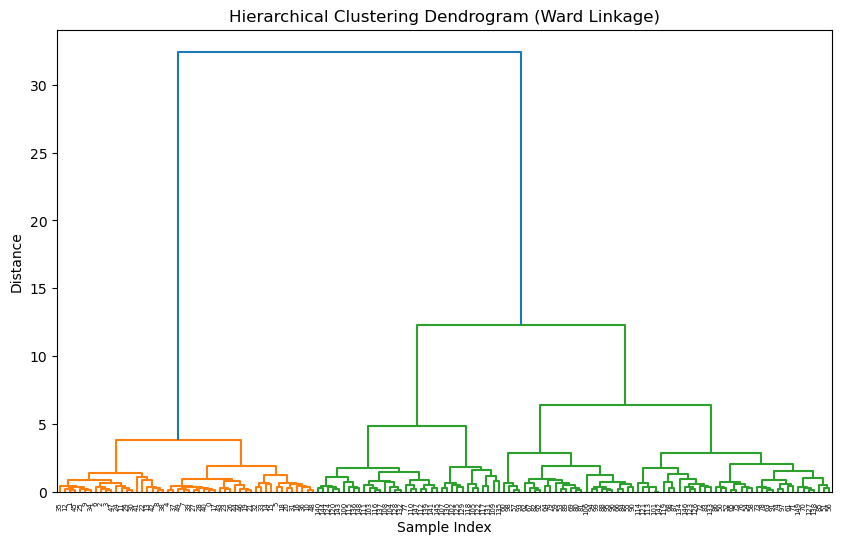

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import linkage, dendrogram

iris = load_iris()
X = iris.data

Z = linkage(X, method='ward')

plt.figure(figsize=(10,6))
dendrogram(Z)

plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")

plt.show()

2. Visually inspect the dendrogram you plotted and cut it at a height that results in 3 distinct clusters. Assign each data point to its cluster and print the number of samples in each cluster.<br><br><em><strong>Hint:</strong> Use scipy's fcluster() with the 'criterion' set to 'distance' and your chosen height.</em>


In [2]:
from scipy.cluster.hierarchy import fcluster
import pandas as pd

threshold = 7

clusters = fcluster(
    Z,
    t=threshold,
    criterion='distance'
)

df = pd.DataFrame(X, columns=iris.feature_names)
df["Cluster"] = clusters

print(df.head())

print("\nSamples in Each Cluster")
print(df["Cluster"].value_counts().sort_index())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Cluster  
0        1  
1        1  
2        1  
3        1  
4        1  

Samples in Each Cluster
Cluster
1    50
2    36
3    64
Name: count, dtype: int64


3. Repeat the dendrogram plotting for the same data using 'single' and 'complete' linkage methods, and compare how the cluster shapes and heights differ from 'ward' linkage.<br><br><em><strong>Hint:</strong> Place all three dendrograms side by side for visual comparison.</em>


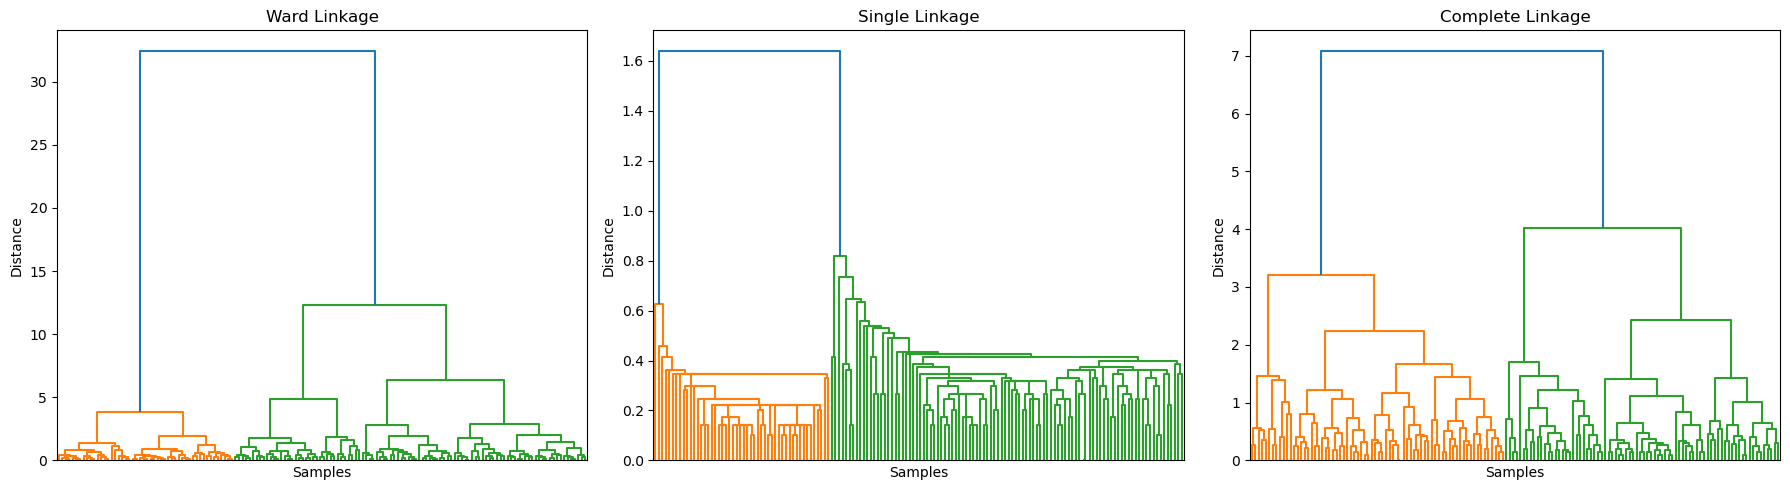

In [3]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

methods = ["ward", "single", "complete"]

plt.figure(figsize=(18,5))

for i, method in enumerate(methods):

    Z = linkage(X, method=method)

    plt.subplot(1,3,i+1)

    dendrogram(
        Z,
        no_labels=True
    )

    plt.title(f"{method.capitalize()} Linkage")
    plt.xlabel("Samples")
    plt.ylabel("Distance")

plt.tight_layout()
plt.show()

4. Interpret the dendrogram you created: Write a short explanation (3-4 lines) describing how you can tell which clusters are most similar and which are most different, based on the heights and structure of the branches.

The dendrogram shows how samples are merged into clusters based on their similarity. Clusters that merge at lower heights are more similar because the distance between them is small. Clusters that merge only at higher heights are more different from each other. By drawing a horizontal line at an appropriate height, we can choose the number of clusters by counting the branches it intersects.